# 비정질 구조 — 실공간 PDF/SRO 분석 (partial + total, 다원소 자동)
체인: **count → g(r) → R(r)=4πr²ρg → G(r)=4πrρ(g−1)** + **ADF** + **AX₄ 사면체 검증**.
모든 그래프는 partial·total을 **따로** 그리고, 곡선/표를 `results/`에 **txt**로 저장한다.
원소·쌍은 trajectory에서 **자동**으로 읽는다.

## 1. Import + 보조함수

In [1]:
import numpy as np, os
import matplotlib.pyplot as plt
import pdf_analysis as pa
%matplotlib inline

def lab(p): return f"{p[0]}-{p[1]}"

def grid(items, draw, ncols=4, w=3.6, h=2.9, suptitle=None):
    n=len(items); nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(w*ncols,h*nrows),squeeze=False)
    axes=axes.ravel()
    for ax,(name,d) in zip(axes,items): draw(ax,name,d)
    for ax in axes[len(items):]: ax.axis('off')
    if suptitle: fig.suptitle(suptitle, y=1.0, fontsize=13)
    fig.tight_layout(); return fig

## 2. 변수 설정 — 여기 값만 바꾼다
> `rho0`(number density)와 구조 1개 vs 여러 개 평균에 대한 설명은 3번 아래 markdown 참고.

In [2]:
TRAJ        = "dump_T0300.lammpstrj"   # ← 분석할 trajectory (같은 폴더)
FRAME_RANGE = (0, None)   # settling 제외: lo 올리기 (예 (20,None))
STRIDE      = 1
R_MAX, NBINS, NBLOCKS = 6.0, 200, 10
ADF_NBINS, ADF_STRIDE = 90, 3          # ADF는 frame 솎아도 통계 충분(속도)
OUTDIR = "results"; os.makedirs(OUTDIR, exist_ok=True)

## 3. 읽기 + 시스템 정보 (원소·쌍 자동, 이웃 캐시)

**`rho0`란?** number density(원자 개수 밀도, atoms/Å³). R(r)=4πr²·ρ·g, G(r)=4πr·ρ·(g−1)
정의의 ρ가 바로 이 number density다(계산엔 반드시 이것). 질량밀도 g/cm³ = rho0 × 평균원자질량 × 1.6605.

**구조 1개 vs 여러 개 평균?**
- *1개 평형구조(혹은 1 trajectory의 frame 평균)로 OK*: 평균 결합길이(peak 위치), 흔한 pair의 평균 CN, density, 각종 peak 위치. (frame 평균은 곡선을 매끄럽게/열앙상블로 만들어 항상 권장)
- *여러 seed 평균 필요*: 에러바(glass 간 변동), 희소 pair 통계(Si–Si·N–N·C–N), 분포의 폭/꼬리, S(Q)/FSDP, 어떤 feature가 실재인지 판별.

In [3]:
frames = pa.read_lammpstrj(TRAJ)
lo,hi = FRAME_RANGE; hi = len(frames) if hi is None else hi
frames = pa.select_frames(frames, (lo,hi), STRIDE)

info  = pa.system_info(frames)
mm    = pa.mean_atomic_mass(frames)
ELEMS = pa.elements(frames)
PAIRS = pa.all_pairs(frames)
CACHE = pa.precompute_neighbors(frames, R_MAX)

print(f"frames = {info['n_frames']},  atoms = {info['natoms']},  elements = {ELEMS}")
print("pairs:", [lab(p) for p in PAIRS])
print("composition:", info['counts'])
print(f"number density rho0 = {info['rho0']:.5f} atoms/Å³   (R/G 정의의 ρ)")
print(f"mass density        = {info['mass_density']:.4f} g/cm³   (= rho0 x {mm:.2f} amu x 1.6605)")

⚠️  truncated final frame at timestep 510000 — 건너뜀.


frames = 110,  atoms = 7775,  elements = ['C', 'N', 'Si']
pairs: ['C-C', 'C-N', 'C-Si', 'N-N', 'N-Si', 'Si-Si']
composition: {'C': 2644, 'N': 1621, 'Si': 3510}
number density rho0 = 0.08366 atoms/Å³   (R/G 정의의 ρ)
mass density        = 2.7347 g/cm³   (= rho0 x 19.69 amu x 1.6605)


## 4. Count histogram — partial + total (각각 따로) + txt 저장

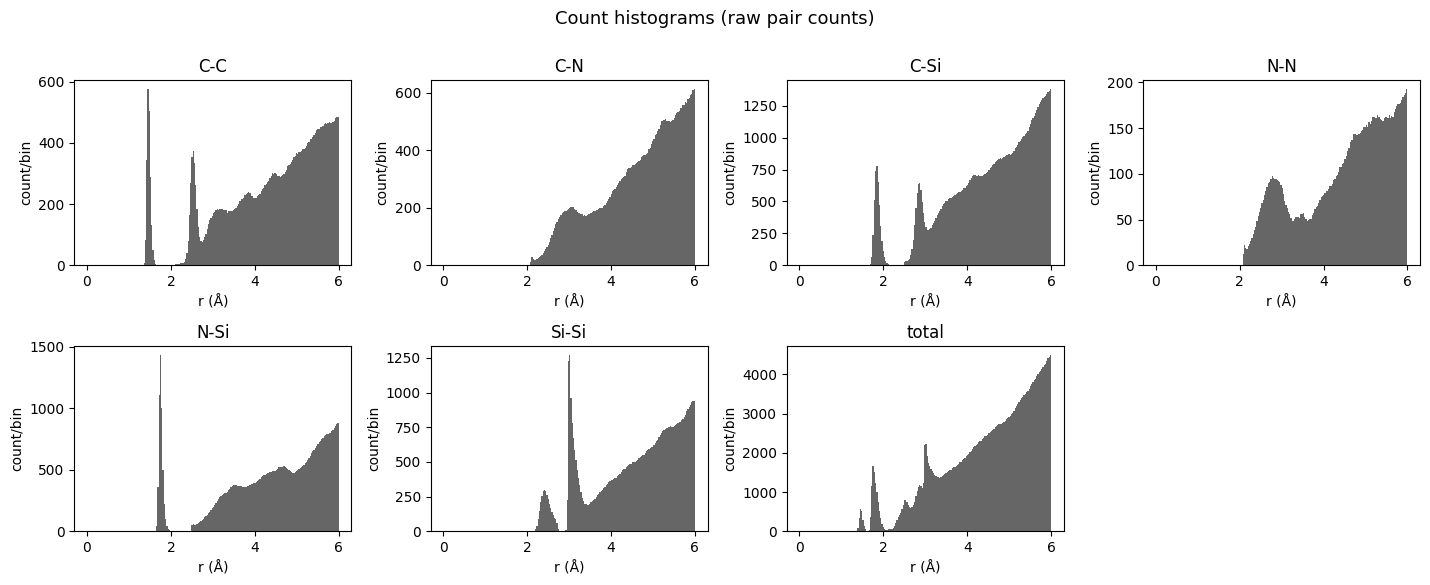

In [4]:
HIST = {p: pa.pair_histogram(frames, p, R_MAX, NBINS, cache=CACHE) for p in PAIRS}
HIST['total'] = pa.pair_histogram(frames, None, R_MAX, NBINS, cache=CACHE)
items = [(lab(p), HIST[p]) for p in PAIRS] + [('total', HIST['total'])]

def draw_h(ax,name,H):
    ax.bar(H['r'], H['counts'], width=R_MAX/NBINS, color='#666')
    ax.set_title(name); ax.set_xlabel('r (Å)'); ax.set_ylabel('count/bin')
fig = grid(items, draw_h, suptitle='Count histograms (raw pair counts)')
fig.savefig(f"{OUTDIR}/count_histograms.png", dpi=140); plt.show()
for name,H in items:
    pa.save_curve(f"{OUTDIR}/count_{name}.txt", H['r'], H['counts'], header='r count')

## 5. g(r) — partial + total (각각 따로, ±1σ) + txt 저장

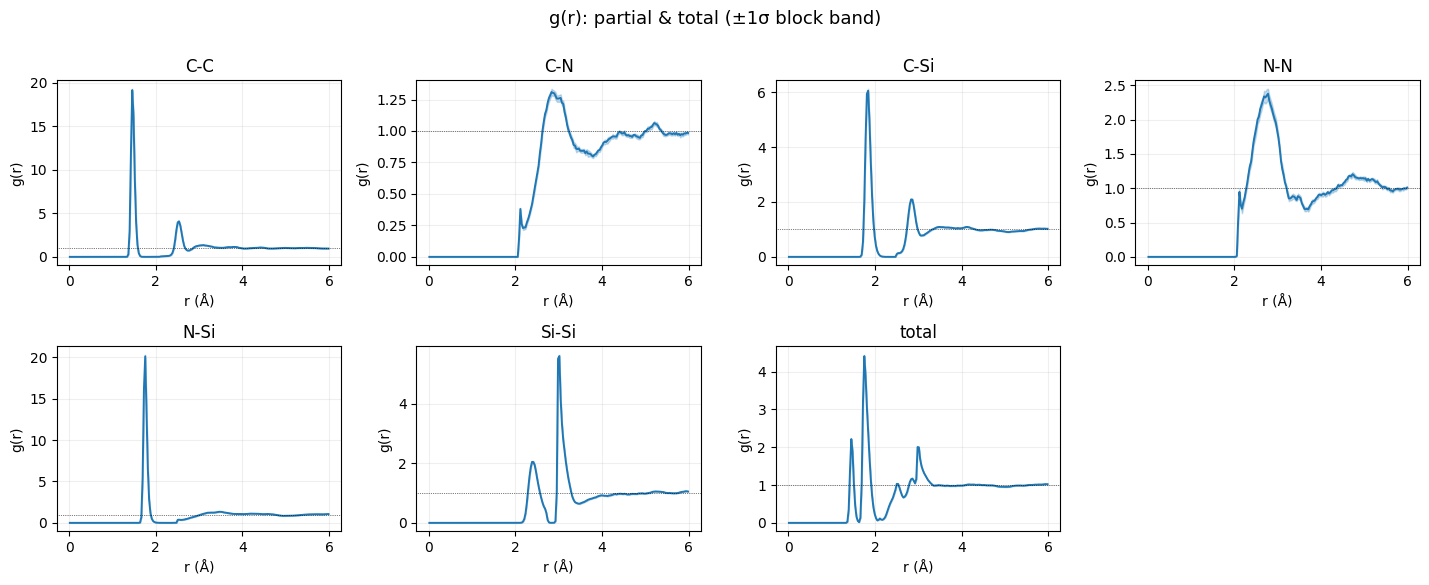

In [5]:
ALLG = {p: pa.rdf_g(frames, p, R_MAX, NBINS, NBLOCKS, cache=CACHE) for p in PAIRS}
TOTG = pa.rdf_g(frames, None, R_MAX, NBINS, NBLOCKS, cache=CACHE)
r = TOTG['r']
items = [(lab(p), ALLG[p]) for p in PAIRS] + [('total', TOTG)]

def draw_g(ax,name,d):
    pa.plot_curve(ax, d['r'], d['g'], err=d['g_err'], color='#1f77b4', baseline=1.0)
    ax.set_title(name); ax.set_ylabel('g(r)')
fig = grid(items, draw_g, suptitle='g(r): partial & total (±1σ block band)')
fig.savefig(f"{OUTDIR}/g_of_r.png", dpi=140); plt.show()
for name,d in items:
    pa.save_curve(f"{OUTDIR}/g_{name}.txt", d['r'], d['g'], err=d['g_err'], header='r g')

## 6. g(r) 측정 — 봉우리 위치·높이·**FWHM** + Gaussian **적합도(R²,RMSE)**
first-peak 자동검출 → 그 주변을 Gaussian 피팅. 봉우리 없으면(결합 없음) 표시.

pair      peak_r  height   FWHM(A)   R^2     RMSE
C-C       1.466   19.15  0.095   0.992  0.515
C-N       2.919    1.32  0.890   0.958  0.034
C-Si      1.842    6.11  0.146   0.984  0.263
N-N       2.735    2.34  0.824   0.992  0.024
N-Si      1.754   20.02  0.092   0.990  0.591
Si-Si     2.429    2.03  0.279   0.955  0.150


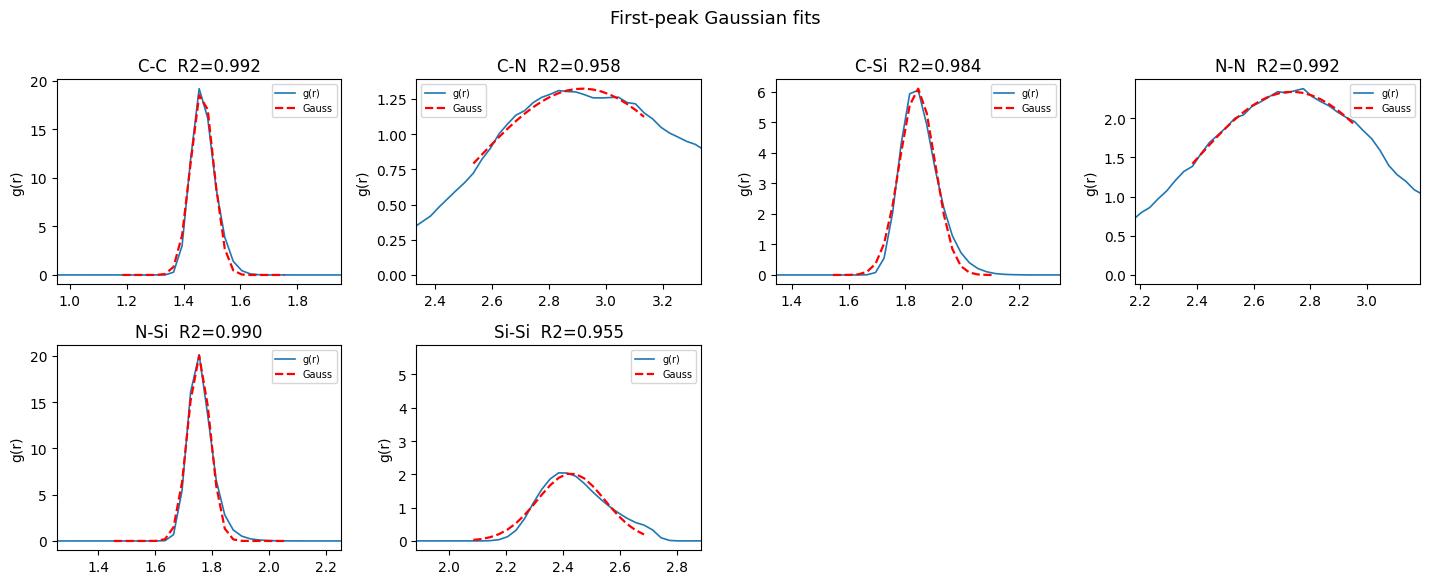

In [6]:
rows = ["pair      peak_r  height   FWHM(A)   R^2     RMSE"]
FITS = {}
for p in PAIRS:
    d = ALLG[p]; fp = pa.first_peak(d['r'], d['g'])
    if fp is None:
        rows.append(f"{lab(p):8s}  (no peak)"); continue
    f = pa.fit_peak(d['r'], d['g'], fp['peak_r'], half_window=0.30); FITS[p]=(fp,f)
    c = f['components'][0]
    rows.append(f"{lab(p):8s}  {c['center']:.3f}  {c['height']:6.2f}  {c['fwhm']:.3f}   {f['r2']:.3f}  {f['rmse']:.3f}")
table = chr(10).join(rows); print(table)
pa.save_text(f"{OUTDIR}/gaussian_fits.txt", table)

fititems = [(lab(p),(p,)+FITS[p]) for p in PAIRS if p in FITS]
def draw_fit(ax,name,t):
    p,fp,f = t
    ax.plot(ALLG[p]['r'], ALLG[p]['g'], color='#1f77b4', lw=1.2, label='g(r)')
    ax.plot(*f['fit'], 'r--', lw=1.6, label='Gauss')
    ax.set_xlim(fp['peak_r']-0.5, fp['peak_r']+0.5)
    ax.set_title(f"{name}  R2={f['r2']:.3f}"); ax.set_ylabel('g(r)'); ax.legend(fontsize=7)
fig = grid(fititems, draw_fit, suptitle='First-peak Gaussian fits')
fig.savefig(f"{OUTDIR}/gaussian_fits.png", dpi=140); plt.show()

## 7. R(r) = 4πr²ρ·g(r) — partial + total (각각) + txt 저장

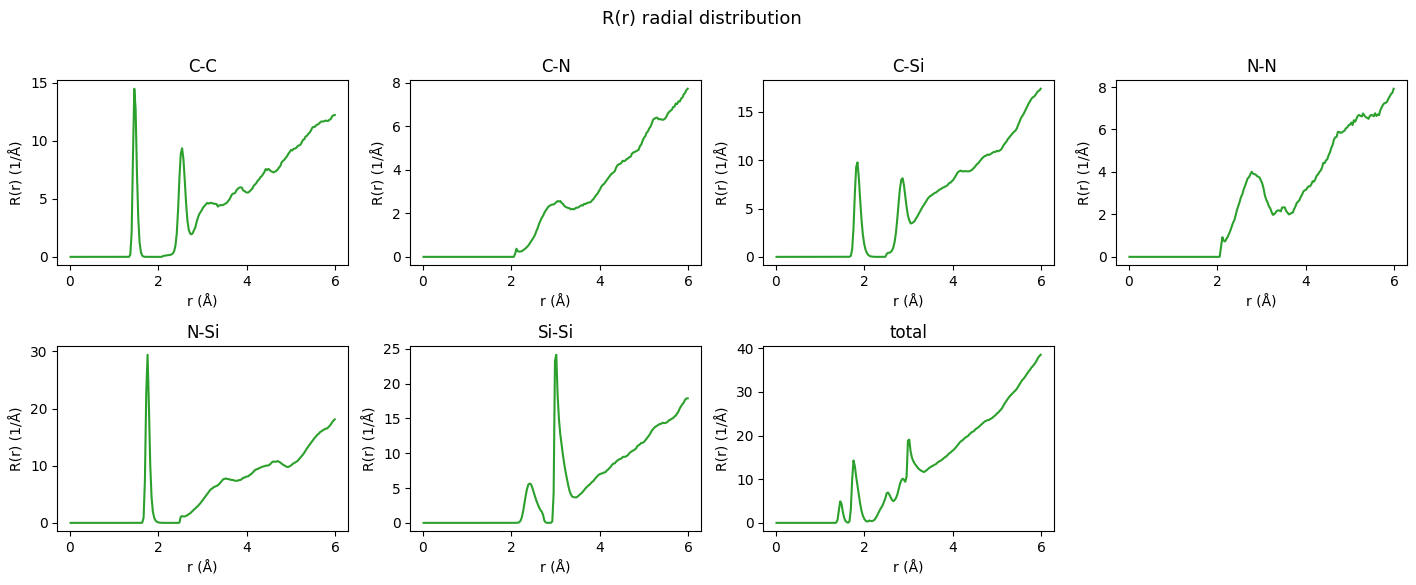

In [7]:
items = [(lab(p), ALLG[p]) for p in PAIRS] + [('total', TOTG)]
def draw_R(ax,name,d):
    R = pa.R_of_r(d['r'], d['g'], d['rho_b'])
    ax.plot(d['r'], R, color='#2ca02c'); ax.set_title(name)
    ax.set_xlabel('r (Å)'); ax.set_ylabel('R(r) (1/Å)')
fig = grid(items, draw_R, suptitle='R(r) radial distribution')
fig.savefig(f"{OUTDIR}/R_of_r.png", dpi=140); plt.show()
for name,d in items:
    R = pa.R_of_r(d['r'], d['g'], d['rho_b'])
    pa.save_curve(f"{OUTDIR}/R_{name}.txt", d['r'], R, header='r R')

## 8. CN — **각 pair만 (total 없음)**, R(r) 적분 + txt 저장

In [8]:
rows = ["a->b      cutoff(A)   CN(int R dr)"]
for A in ELEMS:
    for B in ELEMS:
        d = pa.rdf_g(frames, (A,B), R_MAX, NBINS, NBLOCKS, cache=CACHE)
        fp = pa.first_peak(d['r'], d['g'])
        if fp is None or fp['peak_r'] > 2.6:
            rows.append(f"{A}->{B:<3s}    (no bond)"); continue
        R = pa.R_of_r(d['r'], d['g'], d['rho_b'])
        cn = pa.cn_from_R(d['r'], R, 0.0, fp['min_r'])
        rows.append(f"{A}->{B:<3s}    {fp['min_r']:.3f}      {cn:.3f}")
table = chr(10).join(rows); print(table)
pa.save_text(f"{OUTDIR}/coordination.txt", table)

a->b      cutoff(A)   CN(int R dr)
C->C      2.055      1.515
C->N      (no bond)
C->Si     2.445      1.585
N->C      (no bond)
N->N      (no bond)
N->Si     2.445      2.986
Si->C      2.445      1.194
Si->N      2.445      1.379
Si->Si     2.865      1.724


## 9. Reduced RDF G(r) = 4πrρ·(g−1) — partial + total (각각) + txt 저장

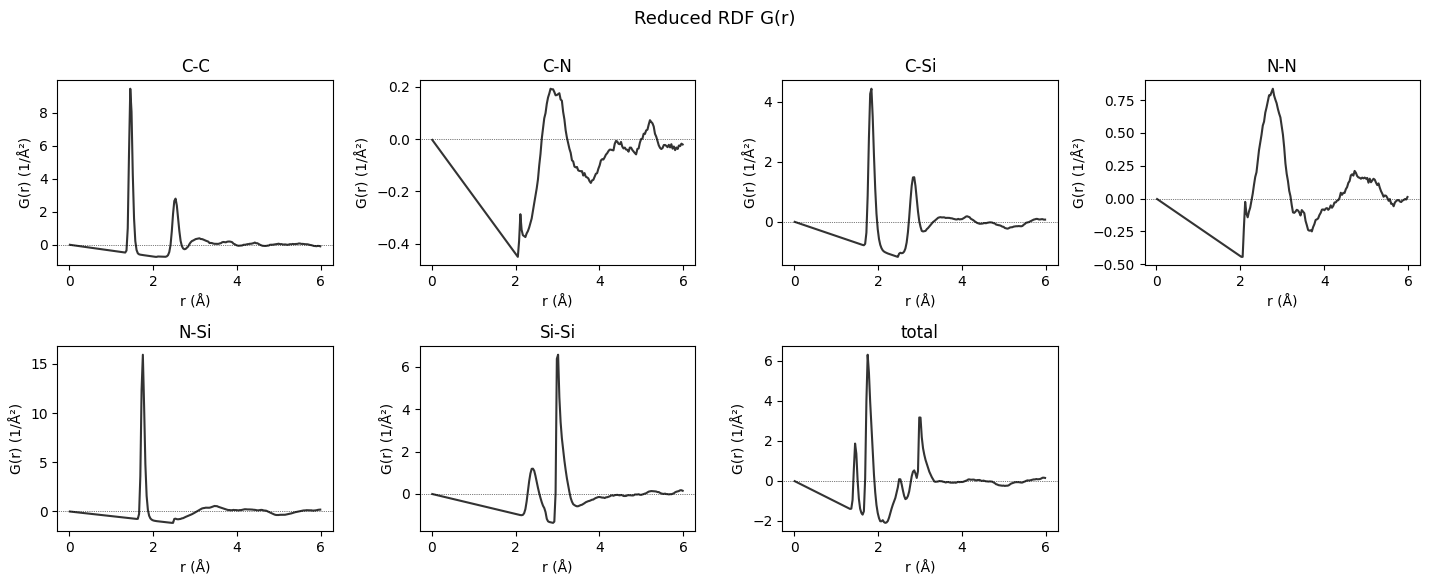

In [9]:
items = [(lab(p), ALLG[p]) for p in PAIRS] + [('total', TOTG)]
def draw_G(ax,name,d):
    rho = d['rho0'] if name=='total' else d['rho_b']
    G = pa.G_of_r(d['r'], d['g'], rho)
    ax.plot(d['r'], G, color='#333'); ax.axhline(0, color='k', lw=0.5, ls=':')
    ax.set_title(name); ax.set_xlabel('r (Å)'); ax.set_ylabel('G(r) (1/Å²)')
fig = grid(items, draw_G, suptitle='Reduced RDF G(r)')
fig.savefig(f"{OUTDIR}/G_of_r.png", dpi=140); plt.show()
for name,d in items:
    rho = d['rho0'] if name=='total' else d['rho_b']
    pa.save_curve(f"{OUTDIR}/G_{name}.txt", d['r'], pa.G_of_r(d['r'], d['g'], rho), header='r G')

## 10. G(r) 측정 — number density(저-r 기울기) → **g/cm³** 자가검증 + txt 저장

from G(r) slope : 0.08366 atoms/A^3  ->  2.7347 g/cm^3
actual N/V      : 0.08366 atoms/A^3  ->  2.7347 g/cm^3
error           : 0.00 %


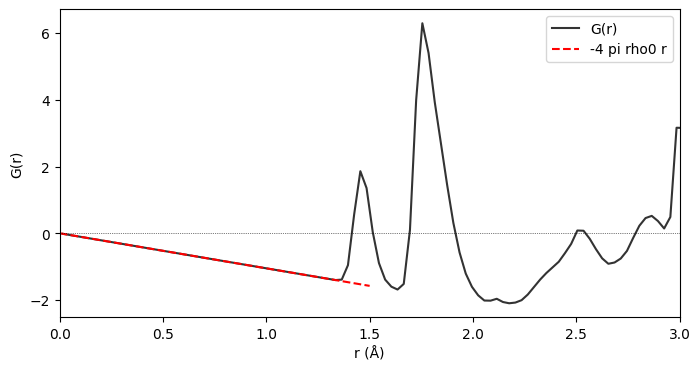

In [10]:
G = pa.G_of_r(TOTG['r'], TOTG['g'], TOTG['rho0'])
rho_est, slope = pa.density_from_G(TOTG['r'], G, 0.4, 1.2)
dens_est = pa.mass_density_gcc(rho_est, mm)
err = 100*abs(rho_est-info['rho0'])/info['rho0']
txt = (f"from G(r) slope : {rho_est:.5f} atoms/A^3  ->  {dens_est:.4f} g/cm^3" + chr(10) +
       f"actual N/V      : {info['rho0']:.5f} atoms/A^3  ->  {info['mass_density']:.4f} g/cm^3" + chr(10) +
       f"error           : {err:.2f} %")
print(txt); pa.save_text(f"{OUTDIR}/density_check.txt", txt)

fig,ax = plt.subplots(figsize=(8,4))
ax.plot(TOTG['r'], G, color='#333', label='G(r)')
rr = np.linspace(0,1.5,50); ax.plot(rr, -4*np.pi*info['rho0']*rr, 'r--', label='-4 pi rho0 r')
ax.axhline(0,color='k',lw=0.5,ls=':'); ax.set_xlim(0,3)
ax.set_xlabel('r (Å)'); ax.set_ylabel('G(r)'); ax.legend(); plt.show()

## 11. ADF — bond angle distribution (partial + total, 각각) + txt 저장
결합 cutoff은 first-peak에서 **자동 제안**(geminal 제외 위해 peak_r<2.6). **출력된 BOND_CUTOFFS가 진짜 결합쌍인지 확인**하고 필요시 수정.

BOND_CUTOFFS (결합쌍만): {'C-C': 2.055, 'C-Si': 2.445, 'N-Si': 2.445, 'Si-Si': 2.865}


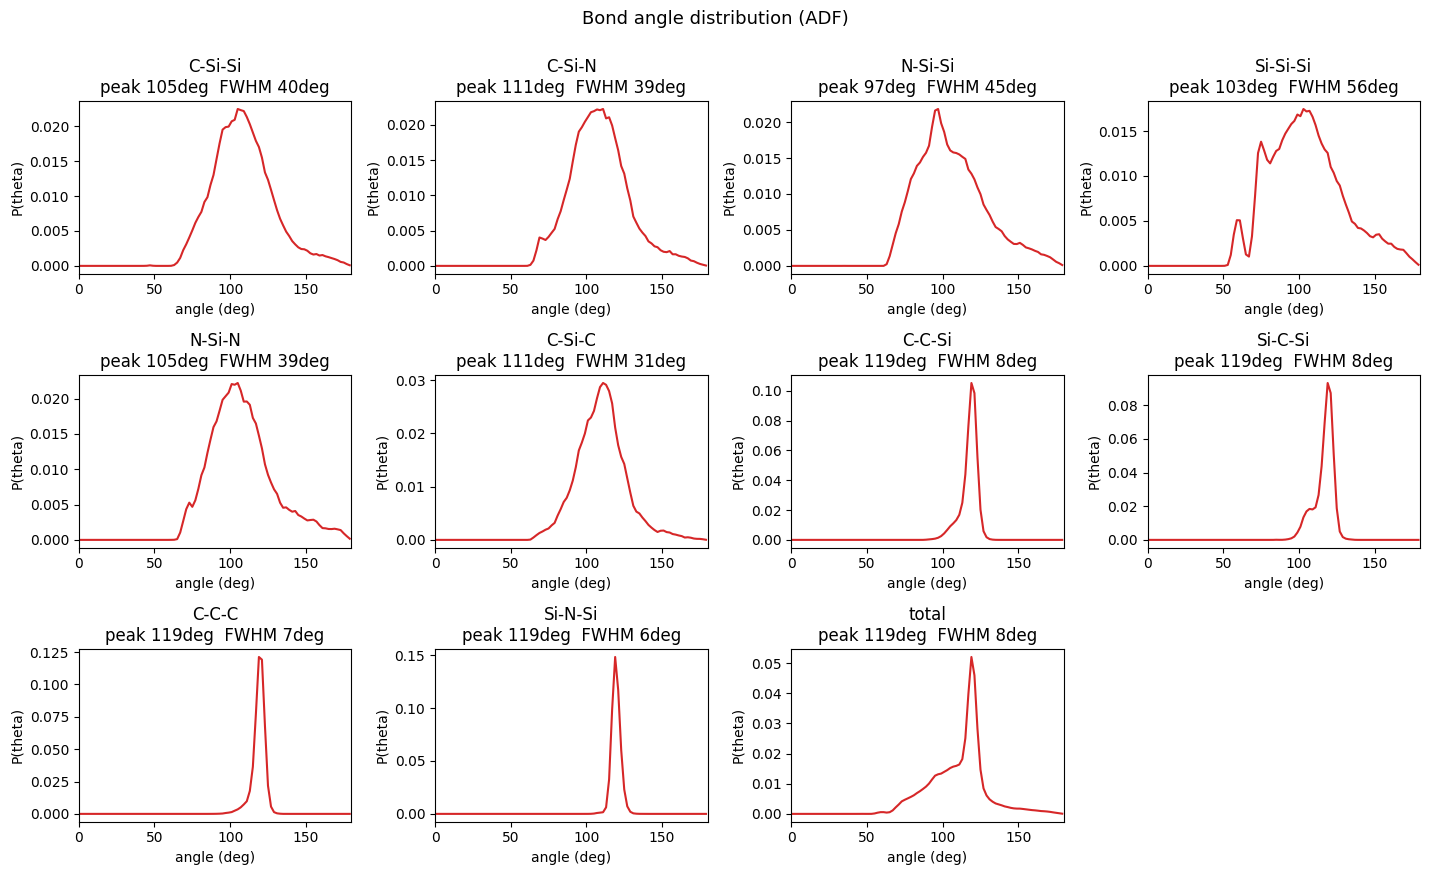

In [11]:
BOND_CUTOFFS = {}
for p in PAIRS:
    fp = pa.first_peak(ALLG[p]['r'], ALLG[p]['g'])
    if fp and fp['peak_r'] < 2.6:
        BOND_CUTOFFS[p] = fp['min_r']
print("BOND_CUTOFFS (결합쌍만):", {lab(k): round(v,3) for k,v in BOND_CUTOFFS.items()})

adf_frames = frames[::ADF_STRIDE]
theta, ADF = pa.adf_all(adf_frames, BOND_CUTOFFS, nbins=ADF_NBINS)
keys = [k for k in ADF if k != ('*','*','*')]
items = [(f"{k[0]}-{k[1]}-{k[2]}", k) for k in keys] + [('total', ('*','*','*'))]

def draw_adf(ax,name,key):
    P = ADF[key]; pk,fw = pa.adf_peak_fwhm(theta, P, (30,175))
    ax.plot(theta, P, color='#d62728')
    ax.set_title(f"{name}\npeak {pk:.0f}deg  FWHM {fw:.0f}deg")
    ax.set_xlabel('angle (deg)'); ax.set_ylabel('P(theta)'); ax.set_xlim(0,180)
fig = grid(items, draw_adf, ncols=4, suptitle='Bond angle distribution (ADF)')
fig.savefig(f"{OUTDIR}/adf.png", dpi=140); plt.show()
for name,k in items:
    pa.save_curve(f"{OUTDIR}/adf_{name}.txt", theta, ADF[k], header='theta P')

## 12. AX₄ 사면체 검증 — r₂/r₁ ↔ 결합각
국소 단위가 **A–X₄ 사면체**라면, 같은 사면체 내 X···X(geminal) 2차거리 r₂는
r₂ = 2·r₁·sin(θ/2), 이상값 θ=109.47° → **r₂/r₁ = 1.633**.
네 가지로 '사면체다'를 증명하고 결합각을 읽는다:
- **위치**: r₂ 예측(=1.633·r₁) vs X–X partial 관측 → θ_PDF
- **화학(partial)**: geminal은 X–X partial에 (A–X 결합거리엔 X–X 없음) → 결합 아닌 geminal 확인
- **폭**: r₂ 폭 예측(=r₁·cos(θ/2)·Δθ_ADF) vs 관측 r₂ 폭
- **개수**: X–X geminal CN 관측 (이상 SiX₄면 X당 3)
마지막으로 θ_PDF(=r₂/r₁) vs θ_ADF(직접) 일치 → 사면체+각 확정.

In [12]:
# 중심 A = 가장 4배위에 가까운(사면체) 양이온 자동 선택
def total_cn(A):
    s=0.0
    for B in ELEMS:
        d=pa.rdf_g(frames,(A,B),R_MAX,NBINS,NBLOCKS,cache=CACHE); fp=pa.first_peak(d['r'],d['g'])
        if fp and fp['peak_r']<2.6:
            s+=pa.cn_from_R(d['r'],pa.R_of_r(d['r'],d['g'],d['rho_b']),0,fp['min_r'])
    return s
A = min(ELEMS, key=lambda e: abs(total_cn(e)-4.0))
# 대표 ligand X = A와 결합하는, 자기 자신이 아닌 원소 중 결합 뚜렷한 것 (여기선 N 우선)
cand = [X for X in ELEMS if X!=A and pa.first_peak(ALLG[(min(A,X),max(A,X))]['r'],ALLG[(min(A,X),max(A,X))]['g'])]
X = 'N' if 'N' in cand else cand[0]
print(f"중심 A = {A} (total CN ~ {total_cn(A):.2f}),  ligand X = {X}")

gAX = ALLG[(min(A,X),max(A,X))]; fpAX = pa.first_peak(gAX['r'],gAX['g'])
fAX = pa.fit_peak(gAX['r'], gAX['g'], fpAX['peak_r'], half_window=0.30)
r1 = fAX['components'][0]['center']
r2_pred, ratio = pa.tetra_geminal(r1)                 # 이상 109.47
gXX = ALLG[(X,X)]; fpXX = pa.first_peak(gXX['r'],gXX['g'])
fXX = pa.fit_peak(gXX['r'], gXX['g'], fpXX['peak_r'], half_window=0.45)
r2_obs = fXX['components'][0]['center']; r2fwhm_obs = fXX['components'][0]['fwhm']
theta_pdf = pa.theta_from_r1r2(r1, r2_obs)

pk_adf, fw_adf = pa.adf_peak_fwhm(theta, ADF[(X,A,X)], (40,175))   # X-A-X 직접 각
r2fwhm_pred = pa.r2_fwhm_from_angle(r1, pk_adf, fw_adf)
# geminal 개수 (X-X geminal 봉우리 적분)
cn_gem = pa.cn_from_R(gXX['r'], pa.R_of_r(gXX['r'],gXX['g'],gXX['rho_b']), fpXX['min_r']-0.6, fpXX['min_r']+0.2)
bondXX = pa.first_peak(gXX['r'], gXX['g'], thresh=1.2)
chem_ok = (r2_obs > 1.4*r1)   # geminal은 결합거리의 ~1.6배 → 결합 아님

rows = [f"=== AX4 검증: {X}-{A}-{X} ===",
        f"위치  : r1(A-X)={r1:.3f} A, r2_pred(1.633*r1)={r2_pred:.3f}, r2_obs(X-X)={r2_obs:.3f}",
        f"        -> theta_PDF = {theta_pdf:.1f} deg",
        f"화학  : geminal이 {X}-{X} partial에 위치 (r2/r1={r2_obs/r1:.3f} ~ 1.633) -> geminal 확인: {chem_ok}",
        f"폭    : r2 FWHM pred(ADF) = {r2fwhm_pred:.3f} A vs obs(Gauss) = {r2fwhm_obs:.3f} A",
        f"개수  : {X}-{X} geminal CN(obs) = {cn_gem:.2f}  (이상 SiX4면 X당 3)",
        f"각도  : theta_PDF = {theta_pdf:.1f} deg  vs  theta_ADF(직접) = {pk_adf:.1f} deg  (ADF FWHM {fw_adf:.0f} deg)",
        f"판정  : 두 경로 차이 {abs(theta_pdf-pk_adf):.1f} deg -> {'사면체 정합' if abs(theta_pdf-pk_adf)<8 else '왜곡/혼합 의심'}"]
out = chr(10).join(rows); print(out); pa.save_text(f"{OUTDIR}/tetra_verification.txt", out)

중심 A = Si (total CN ~ 4.30),  ligand X = N
=== AX4 검증: N-Si-N ===
위치  : r1(A-X)=1.754 A, r2_pred(1.633*r1)=2.864, r2_obs(X-X)=2.733
        -> theta_PDF = 102.3 deg
화학  : geminal이 N-N partial에 위치 (r2/r1=1.558 ~ 1.633) -> geminal 확인: True
폭    : r2 FWHM pred(ADF) = 0.723 A vs obs(Gauss) = 0.824 A
개수  : N-N geminal CN(obs) = 1.94  (이상 SiX4면 X당 3)
각도  : theta_PDF = 102.3 deg  vs  theta_ADF(직접) = 105.0 deg  (ADF FWHM 39 deg)
판정  : 두 경로 차이 2.7 deg -> 사면체 정합


---
저장 위치: `results/` (g/R/G/count/adf 곡선 txt, 그래프 png, gaussian_fits·coordination·density_check·tetra_verification txt)

**다음**: G(r)→S(Q) sine FT(FSDP), 다중 seed 평균(에러바·희소쌍), 다중 T 배치.